<a href="https://colab.research.google.com/github/Andres-Gress/Simulacion-I/blob/main/DistribucionPoisson_Simu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DISTRIBUCIÓN DE POISSON

La distribución de Poisson permite modelar la cantidad de veces que ocurre un evento en un intervalo determinado de tiempo, espacio o cualquier otra unidad de medida. Se utiliza cuando los eventos suceden de manera aleatoria e independiente, pero con una tasa promedio conocida.

La principal característica de la distribución de Poisson es que describe situaciones en las que los eventos son poco frecuentes, pero posibles dentro de un intervalo continuo. Su interpretación se basa en calcular la probabilidad de que ocurra un número específico de eventos cuando se conoce el promedio esperado.

$$P(X=i)=e^{-\lambda} \frac{\lambda^i}{i!}$$

$\lambda$ representa el número promedio de eventos esperados.

$i$ es el número de eventos que se desea analizar

In [211]:
import numpy as np
import random as r
import matplotlib.pyplot as plt
from scipy.special import factorial

Se importan las librerias necesarias

In [212]:
def p(lamda,i):
  return np.exp(-lamda)*lamda**i/factorial(i)

Se define la función de densidad verdadera de la distribución Poisson para comparar con la simulación

In [216]:
def poisson(lamda, i, n):
  l = []
  for j in range(n):
    R = r.random()

    p = np.exp(-lamda)
    F = p
    if R < F:
      x = 0
      l.append(x)
    else:
      for t in range(1,i+1):
        p = lamda*p/(t)
        F = F + p
        if R < F:
          x = t
          l.append(x)
          break
  return l

Se define la función de acuerdo al pseudocódigo planteado, se guardan los elementos en una lista y se retorna la misma lista

In [229]:
n = 10000
lamda = 10
i = 100

P = poisson(lamda, i, n)

Se dan valores a los parámetros:$\quad n,\lambda,i \quad$  

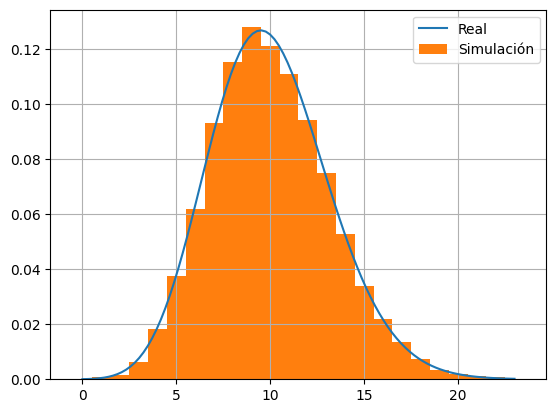

In [231]:
i = np.linspace(0,max(P),100)

plt.plot(i,p(lamda,i), label = "Real")
bins = [] # en el caso discreto los bins son muy necesario definirlos
for i in range(max(P) + 2):
    bins.append(i - 0.5)
plt.hist(P, density = True, label = "Simulación", bins = bins)
plt.legend()
plt.grid()
plt.show()

Se gráfica la aproximación contra la real y se obtienen resultados muy cercanos, cabe destacar que a la simulación para normalizar el histograma se requiere del comando "density = True", pero por ser un caso discreto requiere también de intervalos dados, en nuestro caso los intervalos son los valores de $i$ por lo que mediante un ciclo for se agregan esos intervalos y así la normalización sea la adecuada, en otro caso los resultados difieren.